# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("CONTENT ACTION PLAYBOOK")
print("=" * 60)

# Load data
try:
    df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
    except FileNotFoundError:
        df = pd.read_csv('../data/raw/content_refresh_anonymized.csv')

print(f"Loaded {len(df):,} rows")

CONTENT ACTION PLAYBOOK
Loaded 30,000 rows


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

<small>

### Action Types

| Action | Description | Priority |
|--------|-------------|----------|
| **REVIEW_NOW** | Review immediately — high probability of decline | Highest |
| **REVIEW_SOON** | Review soon — moderate risk | High |
| **MONITOR** | Keep an eye on — low risk, but watch | Medium |
| **LOW_PRIORITY** | Low priority — no action needed now | Low |

### Reason Codes

| Reason Code | Condition | Action |
|-------------|-----------|--------|
| `stale_high_volume` | Stale (≥180 days) + high volume (≥1000 impressions) | REVIEW_NOW |
| `stale_position_risk` | Stale + position ≤ 10 | REVIEW_NOW |
| `volume_priority` | High volume (≥5000 impressions) | REVIEW_SOON |
| `position_opportunity` | Position ≤ 5 | REVIEW_SOON |
| `monitor_routine` | No specific risk identified | MONITOR |

</small>


In [2]:
def assign_action_and_reason(row):
    """Assign action and reason code for each page."""
    staleness = row['days_since_last_update'] >= 180
    volume = row['impressions_90d']
    position = row['avg_position']
    
    if staleness and volume >= 1000:
        return 'REVIEW_NOW', 'stale_high_volume'
    elif staleness and position <= 10:
        return 'REVIEW_NOW', 'stale_position_risk'
    elif volume >= 5000:
        return 'REVIEW_SOON', 'volume_priority'
    elif position <= 5:
        return 'REVIEW_SOON', 'position_opportunity'
    else:
        return 'MONITOR', 'monitor_routine'

# Add actions and reason codes
df['action'], df['reason_code'] = zip(*df.apply(assign_action_and_reason, axis=1))

# Calculate baseline score (from Week 4)
def calculate_baseline_score(row):
    staleness_score = 1.0 if row['days_since_last_update'] >= 180 else 0.0
    volume_score = min(row['impressions_90d'] / 10000, 1.0)
    if row['avg_position'] <= 5:
        position_score = 1.0
    elif row['avg_position'] <= 10:
        position_score = 0.5
    else:
        position_score = 0.0
    return 0.40 * staleness_score + 0.35 * volume_score + 0.25 * position_score

df['score'] = df.apply(calculate_baseline_score, axis=1)

# Rank by score
df_ranked = df.sort_values('score', ascending=False)

print("\nAction Distribution:")
print(df_ranked['action'].value_counts())
print("\nReason Code Distribution:")
print(df_ranked['reason_code'].value_counts())



Action Distribution:
action
MONITOR        19863
REVIEW_SOON    10015
REVIEW_NOW       122
Name: count, dtype: int64

Reason Code Distribution:
reason_code
monitor_routine         19863
volume_priority          6145
position_opportunity     3870
stale_position_risk       110
stale_high_volume          12
Name: count, dtype: int64


### Top 20 Ranked Actions

In [3]:
print("\n" + "=" * 60)
print("TOP 20 RANKED ACTIONS")
print("=" * 60)

top_20 = df_ranked.head(20)[['content_id', 'score', 'action', 'reason_code', 
                              'impressions_90d', 'avg_position', 'days_since_last_update']]
print(top_20.to_string(index=False))


TOP 20 RANKED ACTIONS
          content_id    score     action         reason_code  impressions_90d  avg_position  days_since_last_update
content_cf56e2e2e282 0.750000 REVIEW_NOW   stale_high_volume            61678          19.7                     194
content_7368877ea310 0.750000 REVIEW_NOW   stale_high_volume            59472          24.8                     194
content_1bfaa38ff26c 0.750000 REVIEW_NOW   stale_high_volume            25715          22.2                     194
content_0a91db491d14 0.750000 REVIEW_NOW   stale_high_volume            13299          10.5                     193
content_5feee3994adb 0.673420 REVIEW_NOW   stale_high_volume             7812          39.0                     194
content_c2d929d83eaa 0.664530 REVIEW_NOW   stale_high_volume             7558          17.9                     193
content_ba00ffc6318c 0.662075 REVIEW_NOW stale_position_risk              345           4.9                     211
content_df1fa766cac2 0.657210 REVIEW_NOW stale_po

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

# ### Intended Use (How to Use This Playbook)
# 
> This playbook is designed as a **decision-support tool** for content review teams:
> 
> 1. Reviewers start with pages flagged as `REVIEW_NOW`
> 2. Each page includes a reason code explaining why it was flagged
> 3. Reviewers inspect the page and decide: refresh, archive, or leave as-is
> 4. `REVIEW_SOON` pages are reviewed the following week
> 5. `MONITOR` pages are watched but no immediate action is taken
> 
> ### Limits (Where It Stops Being Valid)
> 
> | Limit | Explanation |
> |-------|-------------|
> | **Proxy label** | The model identifies current-window decline, not future decline |
> | **Starter dataset** | Results are based on the 30,000-row starter dataset; full warehouse results may differ |
> | **No seasonality** | The model cannot distinguish seasonal dips from true decline |
> | **Client variation** | Performance may vary across different clients |
> | **No content understanding** | The model only uses structured signals; it cannot assess content quality |


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

# ### Human Review Rules
# 
> **Reviewers must check:**
> 
> 1. **Seasonality:** Is the traffic drop seasonal? (e.g., retail traffic dropping after holidays)
> 2. **Content quality:** Is the content actually outdated or low-quality?
> 3. **Business importance:** Is this page important for business goals? (lead generation, sales, etc.)
> 4. **Other factors:** Are there other reasons for the drop? (algorithm update, competition)
> 
> ### No-Go List (What Should NEVER Be Automated)
> 
> | What NOT to automate | Why |
> |----------------------|-----|
> | **Automatic refresh** | Content refresh requires human judgment |
> | **Automatic deletion** | Business impact of deletion must be assessed |
> | **Client communication** | Recommendations need human vetting before reaching clients |
> | **Ranking without action** | Ranking without a clear action plan is useless |
> 
> **Policy:** The model recommends, humans decide.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

> ### Monitoring Metrics
> 
> | Metric | Why Track | Threshold |
> |--------|-----------|-----------|
> | **Precision@50** | Model quality | Re-evaluate if < 0.60 |
> | **Recall** | Missed declining pages | Re-evaluate if < 0.50 |
> | **Data drift** | Distribution changes | Retrain if significant drift detected |
> 
> ### Retrain Triggers
> 
> 1. **Quarterly retrain:** Retrain the model every 3 months
> 2. **Performance drop:** Precision@50 drops more than 10%
> 3. **New data:** Significant new data becomes available
> 4. **Business change:** Business goals or client base changes significantly

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

EXPORTS FOR THE PAPER
✅ Ranked queue exported: work/outputs/action_playbook_queue.csv
   Total rows: 30,000
✅ Action distribution chart: work/figures/action_distribution.png


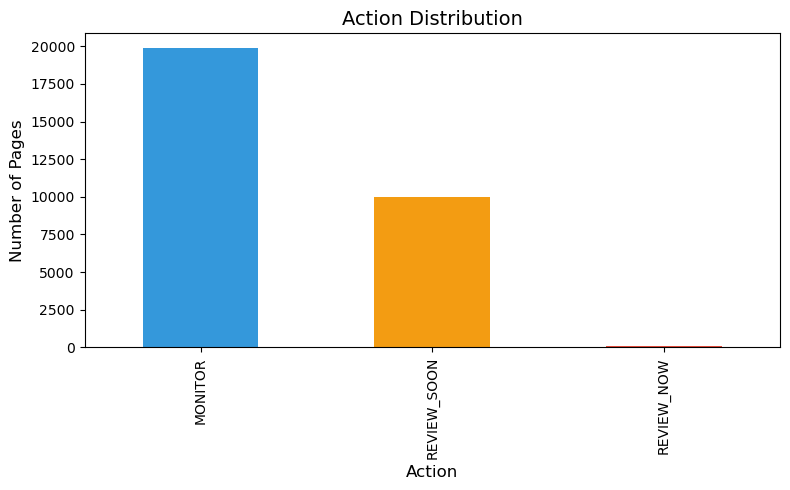

In [7]:
print("=" * 60)
print("EXPORTS FOR THE PAPER")
print("=" * 60)

# Create output directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export ranked queue
export_cols = ['content_id', 'client_id', 'score', 'action', 'reason_code',
               'impressions_90d', 'avg_position', 'ctr', 'content_age_days']
df_export = df_ranked[export_cols].copy()
df_export.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print(f"✅ Ranked queue exported: work/outputs/action_playbook_queue.csv")
print(f"   Total rows: {len(df_export):,}")

# Action distribution chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'REVIEW_NOW': '#E74C3C', 'REVIEW_SOON': '#F39C12', 
          'MONITOR': '#3498DB', 'LOW_PRIORITY': '#95A5A6'}
df_ranked['action'].value_counts().plot(kind='bar', ax=ax, color=[colors.get(x, '#95A5A6') for x in df_ranked['action'].value_counts().index])
ax.set_title('Action Distribution', fontsize=14)
ax.set_xlabel('Action', fontsize=12)
ax.set_ylabel('Number of Pages', fontsize=12)
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png', dpi=150)
print(f"✅ Action distribution chart: work/figures/action_distribution.png")


✅ Score distribution chart: work/figures/score_distribution.png


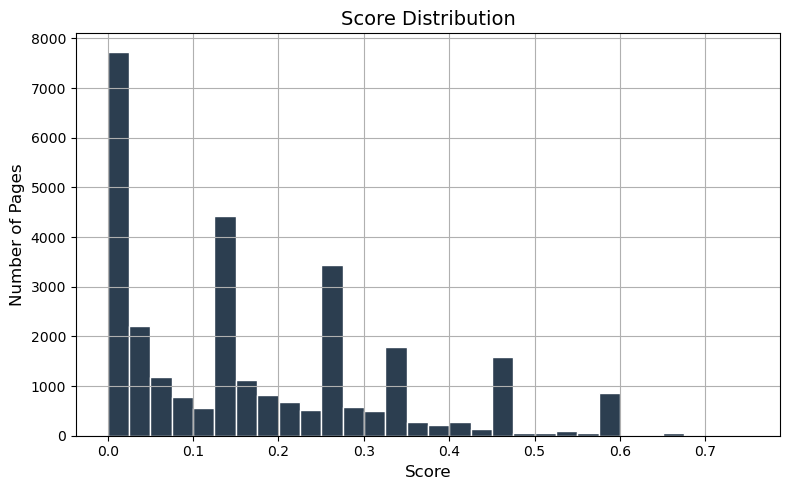

In [8]:
# Score distribution chart
fig, ax = plt.subplots(figsize=(8, 5))
df_ranked['score'].hist(bins=30, ax=ax, color='#2C3E50', edgecolor='white')
ax.set_title('Score Distribution', fontsize=14)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Number of Pages', fontsize=12)
plt.tight_layout()
plt.savefig('work/figures/score_distribution.png', dpi=150)
print(f"✅ Score distribution chart: work/figures/score_distribution.png")

✅ Reason code distribution chart: work/figures/reason_code_distribution.png

✅ All exports complete. Ready for the paper next week.


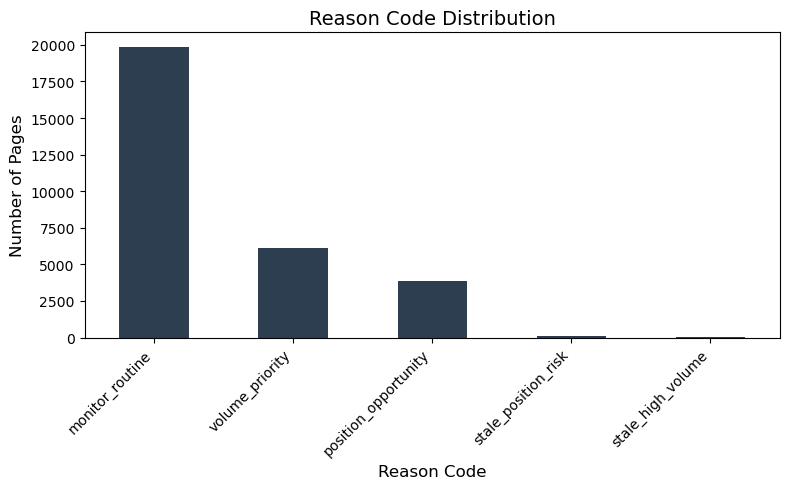

In [9]:
# Reason code distribution chart
fig, ax = plt.subplots(figsize=(8, 5))
df_ranked['reason_code'].value_counts().plot(kind='bar', ax=ax, color='#2C3E50')
ax.set_title('Reason Code Distribution', fontsize=14)
ax.set_xlabel('Reason Code', fontsize=12)
ax.set_ylabel('Number of Pages', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('work/figures/reason_code_distribution.png', dpi=150)
print(f"✅ Reason code distribution chart: work/figures/reason_code_distribution.png")

print("\n✅ All exports complete. Ready for the paper next week.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.